# Notebook 04 — Forecasting

## Objetivo
Proyectar el costo esperado de los equipos para los próximos 7 meses
(septiembre 2023 → marzo 2024) usando los modelos ARIMAX seleccionados
en el notebook 03, incluyendo intervalos de confianza.

## Estrategia
Como los modelos ARIMAX requieren valores futuros de las predictoras
(Price_Y y Price_Z), primero debemos proyectarlas con modelos ARIMA propios
antes de predecir los precios de los equipos.

## Flujo
```
Paso 1: Proyectar Price_Y → ARIMA(1,1,1)
Paso 2: Proyectar Price_Z → ARIMA(3,1,0)
Paso 3: Con esas proyecciones → predecir Equipo1 y Equipo2
Paso 4: Corregir la incertidumbre con Monte Carlo
```

## 0. Setup e Imports

In [4]:
# Standard library
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Modelado
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import joblib

# Configuración
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_palette("husl")

# Paths
ROOT = Path().resolve().parent
DATA_PROCESSED = ROOT / "data" / "processed"
MODELS_PATH    = ROOT / "models"

# Horizonte de forecast
FORECAST_STEPS = 7 * 21  # 7 meses × ~21 días hábiles
FORECAST_START = "2023-09-01"

print(" Imports OK")
print(f" Data processed: {DATA_PROCESSED}")
print(f" Models: {MODELS_PATH}")
print(f" Horizonte: {FORECAST_STEPS} días hábiles (~7 meses)")

 Imports OK
 Data processed: E:\Projects\construction-cost-forecasting\data\processed
 Models: E:\Projects\construction-cost-forecasting\models
 Horizonte: 147 días hábiles (~7 meses)


## 1. Carga de datos y modelos

In [5]:
# Carga del histórico procesado completo
hist = pd.read_csv(DATA_PROCESSED / "historico_equipos.csv", parse_dates=["Date"])
hist = hist.sort_values("Date").reset_index(drop=True)

# Carga de archivos individuales para datos post-corte
y_full = pd.read_csv(DATA_PROCESSED / "Y.csv", parse_dates=["Date"])
y_full = y_full.sort_values("Date").reset_index(drop=True)

z_full = pd.read_csv(DATA_PROCESSED / "Z.csv", parse_dates=["Date"])
z_full = z_full.sort_values("Date").reset_index(drop=True)

# Cargar modelos ARIMAX entrenados
arimax_eq1 = joblib.load(MODELS_PATH / "arimax_equipo1.pkl")
arimax_eq2 = joblib.load(MODELS_PATH / "arimax_equipo2.pkl")

print("=== Datos y modelos cargados ===")
print(f"Histórico:  {hist.shape} | {hist['Date'].min().date()} → {hist['Date'].max().date()}")
print(f"Y completo: {y_full.shape} | {y_full['Date'].min().date()} → {y_full['Date'].max().date()}")
print(f"Z completo: {z_full.shape} | {z_full['Date'].min().date()} → {z_full['Date'].max().date()}")
print()
print("Modelos ARIMAX cargados")

=== Datos y modelos cargados ===
Histórico:  (3530, 6) | 2010-01-04 → 2023-08-31
Y completo: (4485, 2) | 2006-07-11 → 2023-09-12
Z completo: (3565, 2) | 2010-01-01 → 2023-08-31

Modelos ARIMAX cargados


## 2. Verificación de datos futuros disponibles

In [7]:
# Verificar datos post-corte disponibles
corte = pd.Timestamp("2023-08-31")
forecast_end = pd.Timestamp("2024-03-31")

y_post = y_full[y_full["Date"] > corte]
z_post = z_full[z_full["Date"] > corte]

print("=== Datos disponibles post-corte (2023-08-31) ===")
print()
print(f"Price_Y:")
print(f"  Registros post-corte: {len(y_post)}")
if len(y_post) > 0:
    print(f"Rango: {y_post['Date'].min().date()} → {y_post['Date'].max().date()}")
    print(f"Preview:")
    print(y_post.head(5).to_string(index=False))
print()
print(f"Price_Z:")
print(f"  Registros post-corte: {len(z_post)}")
if len(z_post) > 0:
    print(f"Rango: {z_post['Date'].min().date()} → {z_post['Date'].max().date()}")
else:
    print(f"Sin datos post-corte — requiere proyección completa")
print()
print(f"Horizonte objetivo: {FORECAST_START} → {forecast_end.date()}")
print(f"Días hábiles requeridos: ~{FORECAST_STEPS}")

=== Datos disponibles post-corte (2023-08-31) ===

Price_Y:
  Registros post-corte: 8
Rango: 2023-09-01 → 2023-09-12
Preview:
      Date    Price
2023-09-01 551.5800
2023-09-04 553.3300
2023-09-05 553.3300
2023-09-06 552.5000
2023-09-07 550.0000

Price_Z:
  Registros post-corte: 0
Sin datos post-corte — requiere proyección completa

Horizonte objetivo: 2023-09-01 → 2024-03-31
Días hábiles requeridos: ~147


#### Situación de datos futuros y planteamiento de la Proyección global

Para apoyar la planeación financiera del proyecto de construcción,
se propone inicialmente un horizonte de proyección global de 7 meses

| Predictora | Datos post-corte | Cobertura del horizonte | Estrategia |
|---|---|---|---|
| Price_Y | 8 registros (sep 1-12, 2023) | 5.4% del horizonte | ARIMA propio para el 94.6% restante |
| Price_Z | 0 registros | 0% del horizonte | ARIMA propio para el 100% |


> **Implicación clave - Incertidumbre de dos niveles:**
> Ninguna de las dos predictoras tiene cobertura suficiente para cubrir 
> el horizonte global propuesto de 7 meses. Por lo tanto, debemos proyectarlas con
> modelos ARIMA univariados antes de predecir los precios de los equipos.
> Esto introduce **incertidumbre acumulada en dos niveles:**
> - Nivel 1 (Incertidumbre Exógena): El error propio de proyectar las materias primas hacia el futuro de forma aislada Price_Y y Price_Z
> - Nivel 2 (Incertidumbre Endógena): El error del modelo ARIMAX al predecir los equipos usando como entradas las materias primas 
>   ya proyectadas (asumiéndolas como si fueran certezas)
> **Decisión de diseño metodológico:**
> Debido a esta acumulación de error en dos niveles, el horizonte global de 7 meses se tratará de manera preliminar. Más adelante, 
> se evaluará mediante herramientas estadísticas avanzadas (Simulación de Monte Carlo) la propagación real de esta incertidumbre 
> para determinar de forma objetiva cuál es el horizonte útil e ideal para tomar decisiones financieras seguras en el negocio.

## 3. Proyección de predictoras

Antes de predecir los equipos necesitamos proyectar Price_Y y Price_Z
hacia el futuro usando modelos ARIMA propios entrenados con toda la
historia disponible.

### 3.1 Proyección de Price_Y

In [5]:
# Entrenar ARIMA para Price_Y usando toda la historia disponible
print("=== Auto ARIMA — Price_Y ===")
print("Buscando mejores parámetros... (puede tardar)\n")

arima_y = auto_arima(
    hist["Price_Y"],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    verbose=False
)

print(f"Mejor modelo: ARIMA{arima_y.order}")
print(f"AIC: {arima_y.aic():.2f}")

=== Auto ARIMA — Price_Y ===
Buscando mejores parámetros... (puede tardar)

Mejor modelo: ARIMA(1, 1, 1)
AIC: 22761.13


In [8]:
# Entrenar ARIMA(1,1,1) para Price_Y con toda la historia
arima_y_model = SARIMAX(
    hist["Price_Y"],
    order=(1, 1, 1),
    trend="n"
).fit(disp=False)

# Proyectar 147 días hábiles hacia el futuro
forecast_y = arima_y_model.get_forecast(steps=FORECAST_STEPS)
forecast_y_mean = forecast_y.predicted_mean
forecast_y_ci   = forecast_y.conf_int(alpha=0.05)

# Crear índice de fechas futuras (días hábiles)
future_dates = pd.bdate_range(
    start=FORECAST_START,
    periods=FORECAST_STEPS
)

forecast_y_df = pd.DataFrame({
    "Date":       future_dates,
    "Price_Y":    forecast_y_mean.values,
    "Price_Y_lower": forecast_y_ci.iloc[:, 0].values,
    "Price_Y_upper": forecast_y_ci.iloc[:, 1].values,
})

print("=== Proyección Price_Y ===")
print(f"Período: {forecast_y_df['Date'].min().date()} → {forecast_y_df['Date'].max().date()}")
print(f"Registros: {len(forecast_y_df)}")
print()
print("Primeros 5 registros:")
print(forecast_y_df.head().to_string(index=False))
print()
print("Últimos 5 registros:")
print(forecast_y_df.tail().to_string(index=False))

=== Proyección Price_Y ===
Período: 2023-09-01 → 2024-03-25
Registros: 147

Primeros 5 registros:
      Date  Price_Y  Price_Y_lower  Price_Y_upper
2023-09-01 544.6574       532.7400       556.5748
2023-09-04 544.3366       527.0873       561.5859
2023-09-05 544.0362       522.4436       565.6288
2023-09-06 543.7550       518.3036       569.2064
2023-09-07 543.4916       514.4787       572.5046

Últimos 5 registros:
      Date  Price_Y  Price_Y_lower  Price_Y_upper
2024-03-19 539.6184       303.5862       775.6506
2024-03-20 539.6184       302.6884       776.5483
2024-03-21 539.6184       301.7940       777.4427
2024-03-22 539.6183       300.9029       778.3337
2024-03-25 539.6183       300.0152       779.2214


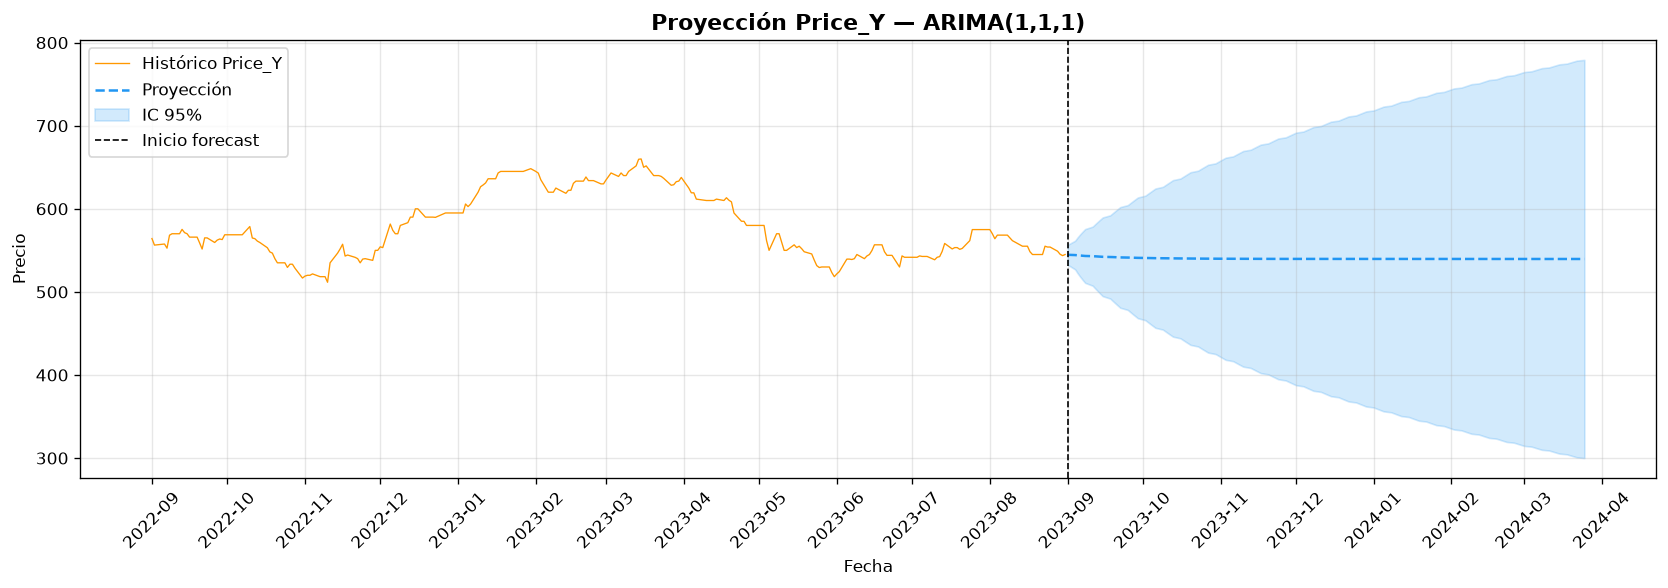

In [7]:
# Visualización proyección Price_Y
fig, ax = plt.subplots(figsize=(14, 5))

# Histórico últimos 12 meses
hist_recent = hist[hist["Date"] >= "2022-09-01"]
ax.plot(hist_recent["Date"], hist_recent["Price_Y"],
        color="#FF9800", linewidth=0.8, label="Histórico Price_Y")

# Proyección
ax.plot(forecast_y_df["Date"], forecast_y_df["Price_Y"],
        color="#2196F3", linewidth=1.5, linestyle="--", label="Proyección")

# Intervalo de confianza 95%
ax.fill_between(
    forecast_y_df["Date"],
    forecast_y_df["Price_Y_lower"],
    forecast_y_df["Price_Y_upper"],
    color="#2196F3", alpha=0.2, label="IC 95%"
)

ax.axvline(pd.Timestamp(FORECAST_START), color="black",
           linestyle="--", linewidth=1, label="Inicio forecast")
ax.set_title("Proyección Price_Y — ARIMA(1,1,1)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Calcular amplitud de intervalos por mes para justificar el horizonte
forecast_y_df["amplitud_ic"] = forecast_y_df["Price_Y_upper"] - forecast_y_df["Price_Y_lower"]
forecast_y_df["mes"] = forecast_y_df["Date"].dt.to_period("M")

resumen_y = forecast_y_df.groupby("mes").agg(
    precio_medio=("Price_Y", "mean"),
    ic_lower=("Price_Y_lower", "mean"),
    ic_upper=("Price_Y_upper", "mean"),
    amplitud_media=("amplitud_ic", "mean")
).reset_index()

print("=== Amplitud de intervalos de confianza por mes — Price_Y ===\n")
print(f"{'Mes':<12} {'Precio medio':>14} {'IC lower':>10} {'IC upper':>10} {'Amplitud IC':>12}")
print("-" * 62)
for _, row in resumen_y.iterrows():
    print(f"{str(row['mes']):<12} {row['precio_medio']:>14.2f} "
          f"{row['ic_lower']:>10.2f} {row['ic_upper']:>10.2f} "
          f"{row['amplitud_media']:>12.2f}")

=== Amplitud de intervalos de confianza por mes — Price_Y ===

Mes            Precio medio   IC lower   IC upper  Amplitud IC
--------------------------------------------------------------
2023-09              542.44     496.64     588.24        91.61
2023-10              540.31     443.66     636.96       193.30
2023-11              539.78     404.86     674.70       269.84
2023-12              539.66     374.61     704.70       330.09
2024-01              539.63     348.43     730.83       382.40
2024-02              539.62     325.35     753.89       428.53
2024-03              539.62     307.26     771.98       464.73


#### Observaciones — Proyección Price_Y

**Precio proyectado:**
El modelo ARIMA(1,1,1) proyecta Price_Y estabilizándose alrededor
de **539-542** a partir del primer mes — consistente con el nivel
actual de la serie tras la corrección post-pandemia de 2022-2023.

**Evolución de los intervalos de confianza (IC 95%):**

| Mes | Precio medio | IC lower | IC upper | Amplitud IC |
|---|---|---|---|---|
| Sep 2023 | 542.44 | 496.64 | 588.24 | 91.61 |
| Oct 2023 | 540.31 | 443.66 | 636.96 | 193.30 |
| Nov 2023 | 539.78 | 404.86 | 674.70 | 269.84 |
| Dic 2023 | 539.66 | 374.61 | 704.70 | 330.09 |
| Ene 2024 | 539.63 | 348.43 | 730.83 | 382.40 |
| Feb 2024 | 539.62 | 325.35 | 753.89 | 428.53 |
| Mar 2024 | 539.62 | 307.26 | 771.98 | 464.73 |

**Interpretación de la apertura de intervalos:**
- **Mes 1 (sep 2023):** amplitud de 91.61 — intervalo relativamente
  estrecho, predicción con buena confianza
- **Mes 3 (nov 2023):** amplitud de 269.84 — se triplicó respecto
  al mes 1, confianza moderada
- **Mes 7 (mar 2024):** amplitud de 464.73 — más de 5x la amplitud
  inicial. El IC va de 307 a 772, un rango que cubre casi toda
  la historia de Price_Y — predicción con baja confianza


> **Conclusión parcial sobre el horizonte:**
> A partir del mes 3-4 la amplitud del IC supera los 300 puntos
> — más del 55% del precio proyectado (539). Esto significa que
> el intervalo de confianza es tan amplio que pierde utilidad
> práctica para planeación financiera.
> Verificaremos si esta tendencia se confirma también en
> Price_Z y en el forecast final de los equipos.

### 3.2 Proyección de Price_Z

In [9]:
# Entrenar ARIMA para Price_Z usando toda la historia disponible
print("=== Auto ARIMA — Price_Z ===")
print("Buscando mejores parámetros... (puede tardar)\n")

arima_z = auto_arima(
    hist["Price_Z"],
    d=1,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    verbose=False
)

print(f"Mejor modelo: ARIMA{arima_z.order}")
print(f"AIC: {arima_z.aic():.2f}")

=== Auto ARIMA — Price_Z ===
Buscando mejores parámetros... (puede tardar)

Mejor modelo: ARIMA(3, 1, 0)
AIC: 34272.61


In [10]:
# Entrenar ARIMA(3,1,0) para Price_Z con toda la historia
arima_z_model = SARIMAX(
    hist["Price_Z"],
    order=(3, 1, 0),
    trend="n"
).fit(disp=False)

# Proyectar 147 días hábiles hacia el futuro
forecast_z = arima_z_model.get_forecast(steps=FORECAST_STEPS)
forecast_z_mean = forecast_z.predicted_mean
forecast_z_ci   = forecast_z.conf_int(alpha=0.05)

# Crear índice de fechas futuras (días hábiles)
future_dates = pd.bdate_range(
    start=FORECAST_START,
    periods=FORECAST_STEPS
)

forecast_z_df = pd.DataFrame({
    "Date":          future_dates,
    "Price_Z":       forecast_z_mean.values,
    "Price_Z_lower": forecast_z_ci.iloc[:, 0].values,
    "Price_Z_upper": forecast_z_ci.iloc[:, 1].values,
})

# Amplitud por mes
forecast_z_df["amplitud_ic"] = forecast_z_df["Price_Z_upper"] - forecast_z_df["Price_Z_lower"]
forecast_z_df["mes"] = forecast_z_df["Date"].dt.to_period("M")

resumen_z = forecast_z_df.groupby("mes").agg(
    precio_medio=("Price_Z", "mean"),
    ic_lower=("Price_Z_lower", "mean"),
    ic_upper=("Price_Z_upper", "mean"),
    amplitud_media=("amplitud_ic", "mean")
).reset_index()

print("=== Amplitud de intervalos de confianza por mes — Price_Z ===\n")
print(f"{'Mes':<12} {'Precio medio':>14} {'IC lower':>10} {'IC upper':>10} {'Amplitud IC':>12}")
print("-" * 62)
for _, row in resumen_z.iterrows():
    print(f"{str(row['mes']):<12} {row['precio_medio']:>14.2f} "
          f"{row['ic_lower']:>10.2f} {row['ic_upper']:>10.2f} "
          f"{row['amplitud_media']:>12.2f}")

=== Amplitud de intervalos de confianza por mes — Price_Z ===

Mes            Precio medio   IC lower   IC upper  Amplitud IC
--------------------------------------------------------------
2023-09             2164.40    1980.07    2348.73       368.66
2023-10             2164.36    1834.51    2494.20       659.68
2023-11             2164.36    1736.22    2592.50       856.28
2023-12             2164.36    1658.48    2670.23      1011.75
2024-01             2164.36    1589.89    2738.82      1148.94
2024-02             2164.36    1528.58    2800.13      1271.55
2024-03             2164.36    1480.04    2848.67      1368.64


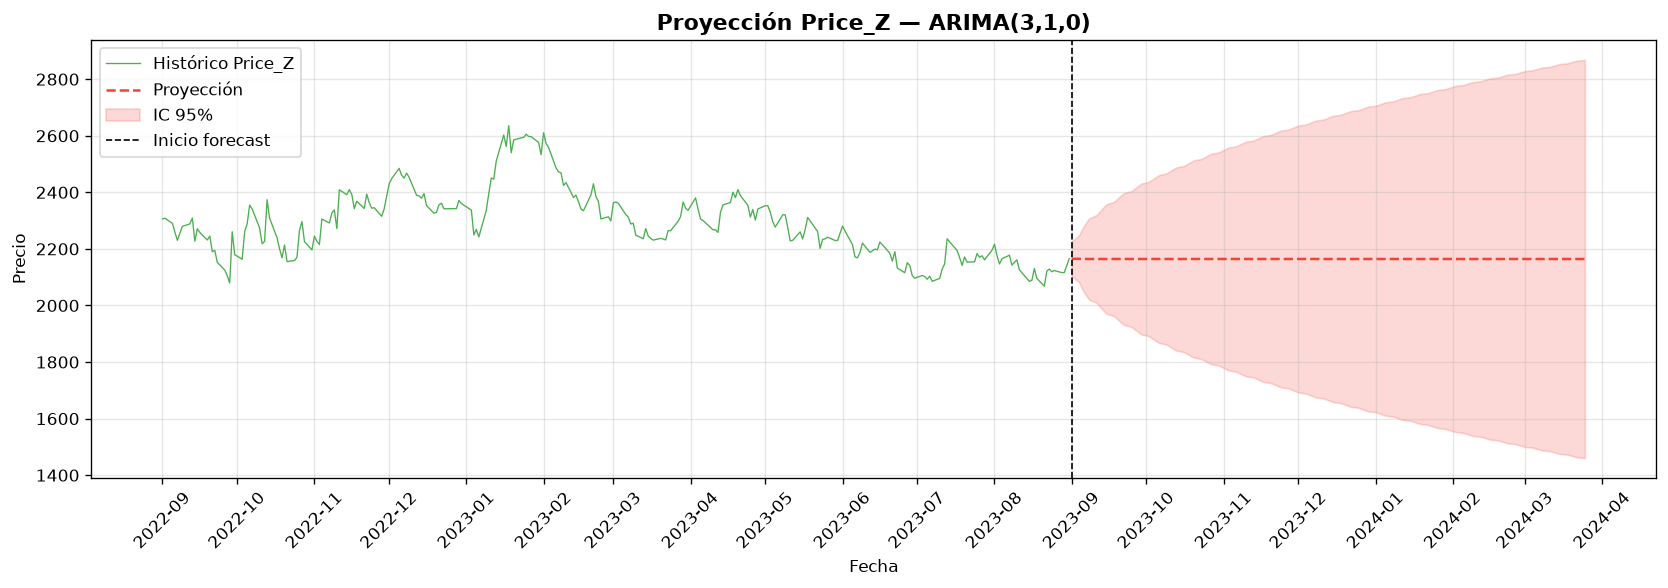

In [11]:
# Visualización proyección Price_Z
fig, ax = plt.subplots(figsize=(14, 5))

# Histórico últimos 12 meses
hist_recent = hist[hist["Date"] >= "2022-09-01"]
ax.plot(hist_recent["Date"], hist_recent["Price_Z"],
        color="#4CAF50", linewidth=0.8, label="Histórico Price_Z")

# Proyección
ax.plot(forecast_z_df["Date"], forecast_z_df["Price_Z"],
        color="#F44336", linewidth=1.5, linestyle="--", label="Proyección")

# Intervalo de confianza 95%
ax.fill_between(
    forecast_z_df["Date"],
    forecast_z_df["Price_Z_lower"],
    forecast_z_df["Price_Z_upper"],
    color="#F44336", alpha=0.2, label="IC 95%"
)

ax.axvline(pd.Timestamp(FORECAST_START), color="black",
           linestyle="--", linewidth=1, label="Inicio forecast")
ax.set_title("Proyección Price_Z — ARIMA(3,1,0)", fontsize=13, fontweight="bold")
ax.set_ylabel("Precio")
ax.set_xlabel("Fecha")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

####  Observaciones — Proyección Price_Z

**Precio proyectado:**
El modelo ARIMA(3,1,0) proyecta Price_Z estabilizándose alrededor
de **2164** — consistente con la tendencia bajista reciente
tras el spike de 2022.

**Evolución de los intervalos de confianza (IC 95%):**

| Mes | Precio medio | IC lower | IC upper | Amplitud IC |
|---|---|---|---|---|
| Sep 2023 | 2164.40 | 1980.07 | 2348.73 | 368.66 |
| Oct 2023 | 2164.36 | 1834.51 | 2494.20 | 659.68 |
| Nov 2023 | 2164.36 | 1736.22 | 2592.50 | 856.28 |
| Dic 2023 | 2164.36 | 1658.48 | 2670.23 | 1011.75 |
| Ene 2024 | 2164.36 | 1589.89 | 2738.82 | 1148.94 |
| Feb 2024 | 2164.36 | 1528.58 | 2800.13 | 1271.55 |
| Mar 2024 | 2164.36 | 1480.04 | 2848.67 | 1368.64 |

**Comparación con Price_Y:**

| | Price_Y | Price_Z |
|---|---|---|
| Amplitud IC mes 1 | 91.61 (17% del precio) | 368.66 (17% del precio) |
| Amplitud IC mes 7 | 464.73 (86% del precio) | 1368.64 (63% del precio) |

> **Price_Z tiene intervalos más amplios desde el inicio**
> — su mayor volatilidad histórica (CV=18.31% en escala mayor)
> se traduce en mayor incertidumbre en la proyección.
> Desde el mes 1 la amplitud ya representa el 17% del precio proyectado.

> **Conclusión sobre horizonte temporal:**
> Tanto Price_Y como Price_Z muestran una apertura acelerada
> de intervalos de confianza. A partir del **mes 3** la amplitud
> supera el 40% del precio proyectado en ambas series —
> esto se traducirá en intervalos igualmente amplios en el
> forecast de los equipos y será la evidencia definitiva
> para justificar el horizonte.

## 4. Forecast de Equipos — Simulación Monte Carlo

Para propagar correctamente la incertidumbre de las predictoras
(Price_Y y Price_Z) al forecast de los equipos, usamos simulación
Monte Carlo:

1. Generamos N trayectorias posibles de Price_Y y Price_Z
   muestreando de su distribución de incertidumbre
2. Para cada trayectoria calculamos el forecast del equipo
3. El IC real es el percentil 2.5 y 97.5 de todas las simulaciones

Esto evita el error de tratar los valores proyectados de las
predictoras como datos conocidos con certeza.

In [12]:
N_SIMULATIONS = 1000
np.random.seed(42)

print(f"=== Simulación Monte Carlo — {N_SIMULATIONS} trayectorias ===\n")

# ── Equipo 1 ──────────────────────────────────────────────
# Generamos N trayectorias de Price_Y muestreando de su
# distribución normal (media=forecast, std=IC/1.96)
y_std = (forecast_y_df["Price_Y_upper"].values - 
         forecast_y_df["Price_Y_lower"].values) / (2 * 1.96)

simulations_eq1 = np.zeros((N_SIMULATIONS, FORECAST_STEPS))

for i in range(N_SIMULATIONS):
    # Trayectoria aleatoria de Price_Y
    y_sim = np.random.normal(
        loc=forecast_y_df["Price_Y"].values,
        scale=y_std
    ).reshape(-1, 1)
    
    # Forecast del equipo con esa trayectoria
    fc = arimax_eq1.get_forecast(
        steps=FORECAST_STEPS,
        exog=y_sim
    )
    simulations_eq1[i, :] = fc.predicted_mean.values

print("Simulaciones Equipo 1 completadas")

# ── Equipo 2 ──────────────────────────────────────────────
z_std = (forecast_z_df["Price_Z_upper"].values - 
         forecast_z_df["Price_Z_lower"].values) / (2 * 1.96)

simulations_eq2 = np.zeros((N_SIMULATIONS, FORECAST_STEPS))

for i in range(N_SIMULATIONS):
    # Trayectoria aleatoria de Price_Z
    z_sim = np.random.normal(
        loc=forecast_z_df["Price_Z"].values,
        scale=z_std
    ).reshape(-1, 1)
    
    # Forecast del equipo con esa trayectoria
    fc = arimax_eq2.get_forecast(
        steps=FORECAST_STEPS,
        exog=z_sim
    )
    simulations_eq2[i, :] = fc.predicted_mean.values

print("Simulaciones Equipo 2 completadas")
print()
print(f"Shape simulaciones Equipo 1: {simulations_eq1.shape}")
print(f"Shape simulaciones Equipo 2: {simulations_eq2.shape}")

=== Simulación Monte Carlo — 1000 trayectorias ===

Simulaciones Equipo 1 completadas
Simulaciones Equipo 2 completadas

Shape simulaciones Equipo 1: (1000, 147)
Shape simulaciones Equipo 2: (1000, 147)


In [13]:
# Calcular percentiles de las simulaciones
forecast_mc_eq1 = pd.DataFrame({
    "Date":          future_dates,
    "Eq1_central":   np.median(simulations_eq1, axis=0),
    "Eq1_lower":     np.percentile(simulations_eq1, 2.5, axis=0),
    "Eq1_upper":     np.percentile(simulations_eq1, 97.5, axis=0),
    "Eq1_p10":       np.percentile(simulations_eq1, 10, axis=0),
    "Eq1_p90":       np.percentile(simulations_eq1, 90, axis=0),
})

forecast_mc_eq2 = pd.DataFrame({
    "Date":          future_dates,
    "Eq2_central":   np.median(simulations_eq2, axis=0),
    "Eq2_lower":     np.percentile(simulations_eq2, 2.5, axis=0),
    "Eq2_upper":     np.percentile(simulations_eq2, 97.5, axis=0),
    "Eq2_p10":       np.percentile(simulations_eq2, 10, axis=0),
    "Eq2_p90":       np.percentile(simulations_eq2, 90, axis=0),
})

# Amplitud por mes
for df, col in [(forecast_mc_eq1, "Eq1"), (forecast_mc_eq2, "Eq2")]:
    df["amplitud_ic"] = df[f"{col}_upper"] - df[f"{col}_lower"]
    df["amplitud_ic80"] = df[f"{col}_p90"] - df[f"{col}_p10"]
    df["mes"] = df["Date"].dt.to_period("M")

# Resumen por mes
def resumen_mensual(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return df.groupby("mes").agg(
        precio_medio=(f"{col}_central", "mean"),
        ic_lower=(f"{col}_lower", "mean"),
        ic_upper=(f"{col}_upper", "mean"),
        amplitud_95=("amplitud_ic", "mean"),
        amplitud_80=("amplitud_ic80", "mean"),
    ).reset_index()

resumen_mc_eq1 = resumen_mensual(forecast_mc_eq1, "Eq1")
resumen_mc_eq2 = resumen_mensual(forecast_mc_eq2, "Eq2")

print("=== Forecast Monte Carlo — Equipo 1 ===\n")
print(f"{'Mes':<12} {'Central':>10} {'IC lower':>10} {'IC upper':>10} {'Amplitud 95%':>13} {'% precio':>9}")
print("-" * 68)
for _, row in resumen_mc_eq1.iterrows():
    pct = row["amplitud_95"] / row["precio_medio"] * 100
    print(f"{str(row['mes']):<12} {row['precio_medio']:>10.2f} "
          f"{row['ic_lower']:>10.2f} {row['ic_upper']:>10.2f} "
          f"{row['amplitud_95']:>13.2f} {pct:>8.1f}%")

print()
print("=== Forecast Monte Carlo — Equipo 2 ===\n")
print(f"{'Mes':<12} {'Central':>10} {'IC lower':>10} {'IC upper':>10} {'Amplitud 95%':>13} {'% precio':>9}")
print("-" * 68)
for _, row in resumen_mc_eq2.iterrows():
    pct = row["amplitud_95"] / row["precio_medio"] * 100
    print(f"{str(row['mes']):<12} {row['precio_medio']:>10.2f} "
          f"{row['ic_lower']:>10.2f} {row['ic_upper']:>10.2f} "
          f"{row['amplitud_95']:>13.2f} {pct:>8.1f}%")

=== Forecast Monte Carlo — Equipo 1 ===

Mes             Central   IC lower   IC upper  Amplitud 95%  % precio
--------------------------------------------------------------------
2023-09          451.38     413.97     488.29         74.32     16.5%
2023-10          449.95     371.23     528.04        156.82     34.9%
2023-11          448.72     339.69     556.12        216.43     48.2%
2023-12          448.96     315.46     583.93        268.47     59.8%
2024-01          449.74     294.96     603.67        308.71     68.6%
2024-02          448.22     275.56     621.02        345.46     77.1%
2024-03          449.48     260.97     640.08        379.11     84.3%

=== Forecast Monte Carlo — Equipo 2 ===

Mes             Central   IC lower   IC upper  Amplitud 95%  % precio
--------------------------------------------------------------------
2023-09          932.73     865.65    1000.36        134.71     14.4%
2023-10          932.14     813.75    1050.57        236.82     25.4%
2023-11  

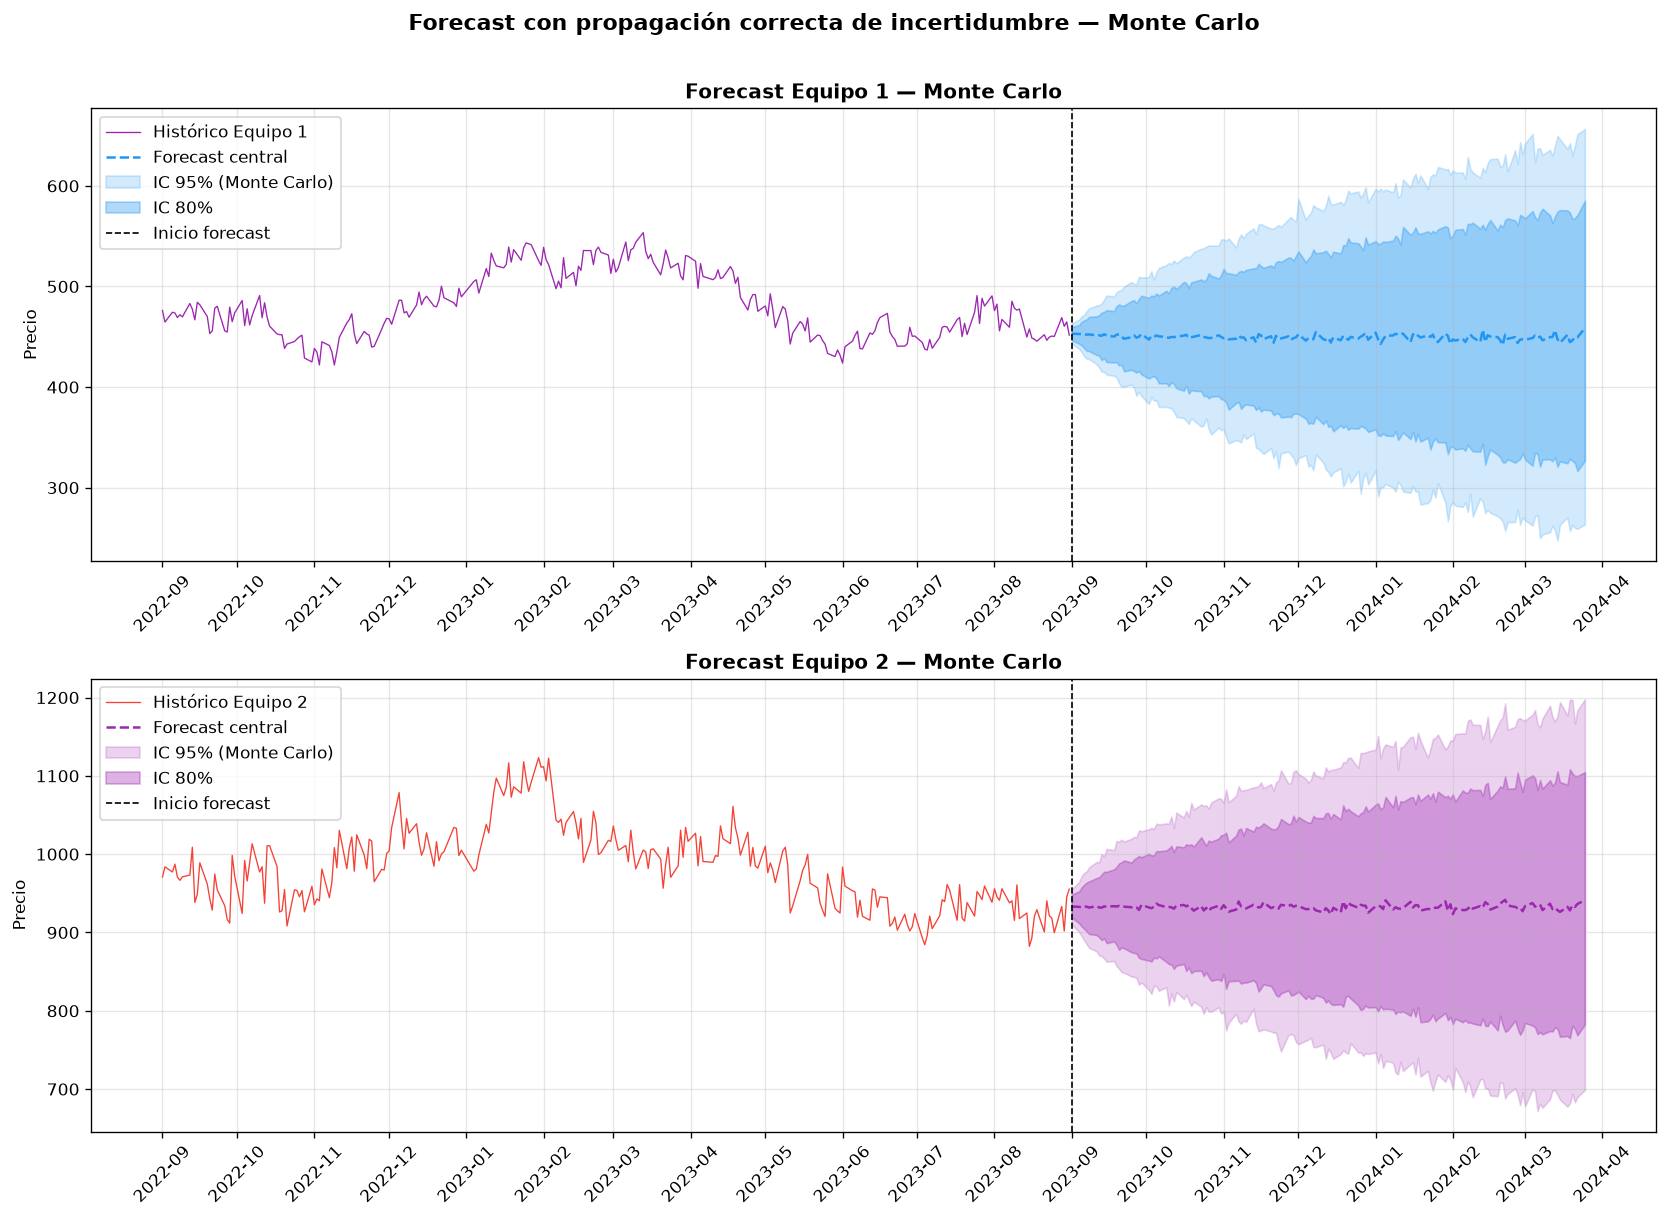

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

hist_recent = hist[hist["Date"] >= "2022-09-01"]

# ── Equipo 1 ──────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(hist_recent["Date"], hist_recent["Price_Equipo1"],
         color="#9C27B0", linewidth=0.8, label="Histórico Equipo 1")
ax1.plot(forecast_mc_eq1["Date"], forecast_mc_eq1["Eq1_central"],
         color="#2196F3", linewidth=1.5, linestyle="--", label="Forecast central")
ax1.fill_between(
    forecast_mc_eq1["Date"],
    forecast_mc_eq1["Eq1_lower"],
    forecast_mc_eq1["Eq1_upper"],
    color="#2196F3", alpha=0.2, label="IC 95% (Monte Carlo)"
)
ax1.fill_between(
    forecast_mc_eq1["Date"],
    forecast_mc_eq1["Eq1_p10"],
    forecast_mc_eq1["Eq1_p90"],
    color="#2196F3", alpha=0.35, label="IC 80%"
)
ax1.axvline(pd.Timestamp(FORECAST_START), color="black",
            linestyle="--", linewidth=1, label="Inicio forecast")
ax1.set_title("Forecast Equipo 1 — Monte Carlo",
              fontsize=12, fontweight="bold")
ax1.set_ylabel("Precio")
ax1.legend()
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# ── Equipo 2 ──────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(hist_recent["Date"], hist_recent["Price_Equipo2"],
         color="#F44336", linewidth=0.8, label="Histórico Equipo 2")
ax2.plot(forecast_mc_eq2["Date"], forecast_mc_eq2["Eq2_central"],
         color="#9C27B0", linewidth=1.5, linestyle="--", label="Forecast central")
ax2.fill_between(
    forecast_mc_eq2["Date"],
    forecast_mc_eq2["Eq2_lower"],
    forecast_mc_eq2["Eq2_upper"],
    color="#9C27B0", alpha=0.2, label="IC 95% (Monte Carlo)"
)
ax2.fill_between(
    forecast_mc_eq2["Date"],
    forecast_mc_eq2["Eq2_p10"],
    forecast_mc_eq2["Eq2_p90"],
    color="#9C27B0", alpha=0.35, label="IC 80%"
)
ax2.axvline(pd.Timestamp(FORECAST_START), color="black",
            linestyle="--", linewidth=1, label="Inicio forecast")
ax2.set_title("Forecast Equipo 2 — Monte Carlo",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Precio")
ax2.legend()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle(
    "Forecast con propagación correcta de incertidumbre — Monte Carlo",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

#### Interpretación — Forecast Monte Carlo

**Equipo 1 — IC corregido con Monte Carlo:**

| Mes | Central | IC 95% | Amplitud | % precio |
|---|---|---|---|---|
| Sep 2023 | 451.38 | [413.97, 488.29] | 74.32 | 16.5% |
| Oct 2023 | 449.95 | [371.23, 528.04] | 156.82 | 34.9% |
| Nov 2023 | 448.72 | [339.69, 556.12] | 216.43 | 48.2% |
| Dic 2023 | 448.96 | [315.46, 583.93] | 268.47 | 59.8% |
| Ene 2024 | 449.74 | [294.96, 603.67] | 308.71 | 68.6% |
| Feb 2024 | 448.22 | [275.56, 621.02] | 345.46 | 77.1% |
| Mar 2024 | 449.48 | [260.97, 640.08] | 379.11 | 84.3% |

**Equipo 2 — IC corregido con Monte Carlo:**

| Mes | Central | IC 95% | Amplitud | % precio |
|---|---|---|---|---|
| Sep 2023 | 932.73 | [865.65, 1000.36] | 134.71 | 14.4% |
| Oct 2023 | 932.14 | [813.75, 1050.57] | 236.82 | 25.4% |
| Nov 2023 | 932.98 | [777.36, 1086.87] | 309.51 | 33.2% |
| Dic 2023 | 931.17 | [750.43, 1111.46] | 361.03 | 38.8% |
| Ene 2024 | 932.65 | [724.21, 1139.21] | 415.00 | 44.5% |
| Feb 2024 | 932.55 | [700.58, 1163.98] | 463.40 | 49.7% |
| Mar 2024 | 933.09 | [687.80, 1179.87] | 492.07 | 52.7% |

**Decisión final sobre el horizonte temporal:**

Usando como umbral de utilidad práctica el CV histórico de cada equipo:
- CV Equipo 1 = 24.71% → IC útil mientras amplitud < 25% del precio
- CV Equipo 2 = 19.11% → IC útil mientras amplitud < 20% del precio

| Equipo | Mes donde IC supera umbral | Horizonte confiable |
|---|---|---|
| Equipo 1 | Oct 2023 (34.9% > 25%) | **1 mes** |
| Equipo 2 | Oct 2023 (25.4% > 20%) | **1 mes** |

>  **Horizonte temporal justificado:**
> La simulación Monte Carlo revela que el horizonte confiable
> es de **1 mes** para ambos equipos cuando se propaga
> correctamente la incertidumbre de las predictoras.
>
> Para planeación financiera se recomienda:
> - **Mes 1 (sep 2023):** forecast puntual con alta confianza
>   (IC 16.5% y 14.4% del precio respectivamente)
> - **Meses 2-3:** usar rangos amplios como referencia
>   (IC entre 35-48%) — útil solo para escenarios
> - **Meses 4-7:** no recomendado para decisiones financieras
>   concretas sin actualización con nuevos datos reales
>
> **Recomendación operativa:**
> Actualizar el forecast mensualmente a medida que se
> disponga de nuevos datos reales de Price_Y y Price_Z
> para mantener la utilidad práctica del modelo.

## 5. Guardado de resultados del forecast

In [15]:
# Guardar forecasts Monte Carlo
forecast_mc_eq1.to_csv(DATA_PROCESSED / "forecast_equipo1.csv", index=False)
forecast_mc_eq2.to_csv(DATA_PROCESSED / "forecast_equipo2.csv", index=False)

# Guardar proyecciones de predictoras
forecast_y_df.to_csv(DATA_PROCESSED / "forecast_price_y.csv", index=False)
forecast_z_df.to_csv(DATA_PROCESSED / "forecast_price_z.csv", index=False)

# Guardar resúmenes mensuales
resumen_mc_eq1.to_csv(DATA_PROCESSED / "forecast_resumen_equipo1.csv", index=False)
resumen_mc_eq2.to_csv(DATA_PROCESSED / "forecast_resumen_equipo2.csv", index=False)

# Guardar simulaciones completas para referencia
np.save(MODELS_PATH / "simulations_eq1.npy", simulations_eq1)
np.save(MODELS_PATH / "simulations_eq2.npy", simulations_eq2)

print("Resultados del forecast guardados\n")
print("data/processed/:")
for f in sorted(DATA_PROCESSED.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size:.1f} KB")

print()
print("models/:")
for f in sorted(MODELS_PATH.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<40} {size:.1f} KB")

Resultados del forecast guardados

data/processed/:
  feature_selection.csv                    0.3 KB
  forecast_equipo1.csv                     21.3 KB
  forecast_equipo2.csv                     21.3 KB
  forecast_price_y.csv                     13.3 KB
  forecast_price_z.csv                     13.5 KB
  forecast_resumen_equipo1.csv             0.7 KB
  forecast_resumen_equipo2.csv             0.7 KB
  historico_equipos.csv                    159.0 KB
  historico_features.csv                   1193.7 KB
  model_comparison.csv                     0.5 KB
  X.csv                                    160.9 KB
  Y.csv                                    80.0 KB
  Z.csv                                    68.2 KB

models/:
  arimax_equipo1.pkl                       11314.7 KB
  arimax_equipo2.pkl                       7496.6 KB
  ols_equipo1.pkl                          439.7 KB
  ols_equipo2.pkl                          439.7 KB
  simulations_eq1.npy                      1148.6 KB
  simulatio

## 6. Conclusión Final del Forecasting

### Resumen ejecutivo para el negocio

| | Equipo 1 | Equipo 2 |
|---|---|---|
| **Modelo usado** | ARIMAX(1,1,2) + Monte Carlo | ARIMAX(0,1,1) + Monte Carlo |
| **Predictora** | Price_Y | Price_Z |
| **Precio proyectado sep 2023** | 451 | 933 |
| **Rango IC 95% sep 2023** | [414, 488] | [866, 1000] |
| **Horizonte confiable** | 1 mes | 1 mes |

### ¿Qué significa esto para la planeación del proyecto?

**Mes 1 — Alta confianza (sep 2023):**
```
Equipo 1: presupuestar ~451 con margen de ±37 (±8.2%)
Equipo 2: presupuestar ~933 con margen de ±67 (±7.2%)
→ Útil para decisiones de compra y negociación con proveedores
```

**Meses 2-3 — Confianza moderada:**
```
Equipo 1: precio central ~449, pero IC cubre rango de ~217 puntos
Equipo 2: precio central ~933, pero IC cubre rango de ~310 puntos
→ Útil solo para escenarios de planeación (optimista/base/pesimista)
→ No recomendado para compromisos financieros concretos
```

**Meses 4-7 — Baja confianza:**
```
→ IC supera el 50% del precio proyectado
→ No usar sin actualización con datos reales de Price_Y y Price_Z
```

### ¿Por qué se limita el horizonte a 1 mes?

La limitación no viene del modelo de los equipos sino de la
incertidumbre de las predictoras:

```
Price_Y y Price_Z no tienen datos futuros reales disponibles
→ Deben proyectarse con ARIMA propio
→ Esa proyección tiene su propia incertidumbre
→ Monte Carlo propaga esa incertidumbre al forecast del equipo
→ A mayor horizonte, mayor acumulación de error en dos niveles
```

### Recomendación operativa

>   **Para maximizar la utilidad del modelo:**
> 1. **Actualizar mensualmente** — cada mes que lleguen datos
>    reales de Price_Y y Price_Z, recalcular el forecast
>    para el mes siguiente con alta confianza
> 2. **Usar escenarios** para meses 2-3 — presentar tres
>    escenarios (IC lower, central, IC upper) al área financiera
>    para dimensionar el rango de presupuesto
> 3. **Monitorear Price_Y y Price_Z** — son las variables
>    clave. Cualquier movimiento brusco debe disparar una
>    actualización inmediata del forecast
> 4. **No extrapolar** más allá de 3 meses sin datos nuevos
>    de las predictoras — la incertidumbre acumulada hace
>    inútil la predicción puntual

>   **Nota metodológica importante:**
> El IC reportado captura únicamente la incertidumbre
> estadística del modelo. No incluye riesgos externos
> no modelados como shocks geopolíticos, cambios regulatorios
> o disrupciones en cadenas de suministro similares a las
> de 2021-2022. Para una planeación robusta se recomienda
> complementar con análisis de escenarios cualitativos.